In [1]:
# # Update the package index
# !sudo apt-get update
# !pip install SciencePlots
# !pip install latex
# !sudo apt-get install dvipng texlive-latex-extra texlive-fonts-recommended cm-super


In [2]:
import contextlib
import os
import itertools, random
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial import distance_matrix
from scipy.optimize import minimize
import math
from collections import Counter

import matplotlib.ticker as ticker
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use('science')

🔧 Cell 1 — Setup & Helpers

In [4]:
# ====== Setup & Helpers ======
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Okabe–Ito color-blind friendly palette (8 colors)
OKABE_ITO = [
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#009E73",  # bluish green
    "#F0E442",  # yellow
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#CC79A7",  # reddish purple
    "#000000",  # black
]

# Use Okabe–Ito as the default color cycle
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=OKABE_ITO)

# Formatters
comma_fmt = FuncFormatter(lambda x, _: f"{int(x):,}")
pct0_fmt  = FuncFormatter(lambda x, _: f"{x:.0f}%")
pct1_fmt  = FuncFormatter(lambda x, _: f"{x:.1f}%")



📈 Cell 2 — Analysis 1: Impact of Launches and Declines

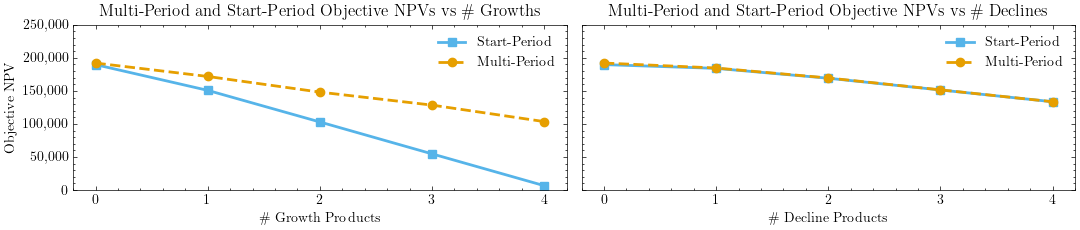

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Keep LaTeX rendering ON (SciencePlots does this automatically)
plt.rcParams["text.usetex"] = True

# Load once
df = pd.read_csv("analysis_1_all_combinations.csv")

# Split into launches-only and declines-only
df_launch = df[df["decline_products"] == 0].copy()
df_decl  = df[df["launch_products"] == 0].copy()

# Calculate differences
df_launch["value_mult_diff"] = df_launch["multi_profit"] - df_launch["single_profit"]
df_decl["value_mult_diff"]  = df_decl["multi_profit"] - df_decl["single_profit"]

# Create 1x2 subplot
fig, axs = plt.subplots(1, 2, figsize=(11, 2.5), sharey=True)

# --- Left panel: Launch products ---
axs[0].plot(df_launch["launch_products"], df_launch["single_profit"],
            marker='s', lw=2, ms=6, label="Start-Period", color=OKABE_ITO[1])
axs[0].plot(df_launch["launch_products"], df_launch["multi_profit"],
            marker='o', lw=2, ms=6, label="Multi-Period", color=OKABE_ITO[0], linestyle="--")
# axs[0].plot(df_launch["launch_products"], df_launch["long_profit"],
#             marker='^', lw=2, ms=6, label="Long Chain",    color=OKABE_ITO[2])

axs[0].set_title(r"Multi-Period and Start-Period Objective NPVs vs \# Growths")#Profits vs \# Launch
axs[0].set_xlabel(r"\# Growth Products")
axs[0].set_ylabel(r"Objective NPV")
axs[0].set_xticks(df_launch["launch_products"])
axs[0].set_ylim(0, 250_000)
axs[0].yaxis.set_major_formatter(comma_fmt)
#axs[0].grid(True, alpha=0.3)
axs[0].legend()

# --- Right panel: Decline products ---
axs[1].plot(df_decl["decline_products"], df_decl["single_profit"],
            marker='s', lw=2, ms=6, label="Start-Period", color=OKABE_ITO[1])
axs[1].plot(df_decl["decline_products"], df_decl["multi_profit"],
            marker='o', lw=2, ms=6, label="Multi-Period", color=OKABE_ITO[0], linestyle="--")

# axs[1].plot(df_decl["decline_products"], df_decl["long_profit"],
#             marker='^', lw=2, ms=6, label="Long Chain",    color=OKABE_ITO[2])

axs[1].set_title(r"Multi-Period and Start-Period Objective NPVs vs \# Declines")#Profits vs \# Declines
axs[1].set_xlabel(r"\# Decline Products")
axs[1].set_xticks(df_decl["decline_products"])
axs[1].set_ylim(0, 250_000)
axs[1].yaxis.set_major_formatter(comma_fmt)
# axs[1].grid(True, alpha=0.3)
axs[1].legend()

plt.tight_layout()
plt.savefig('launchdeclinesv1.pdf')
plt.show()


📊 Analysis 3 — Launches vs Unit Operating Profit

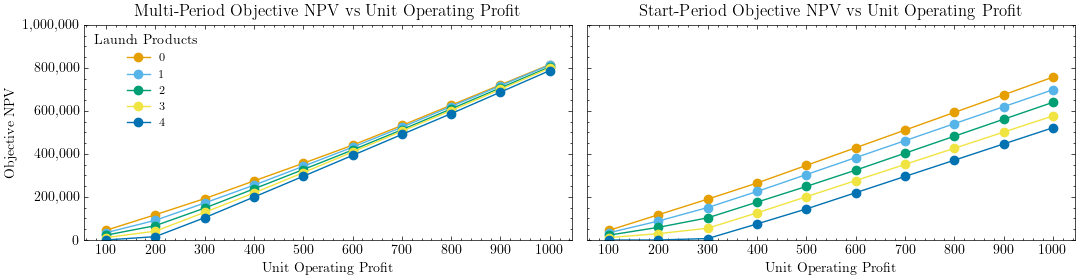

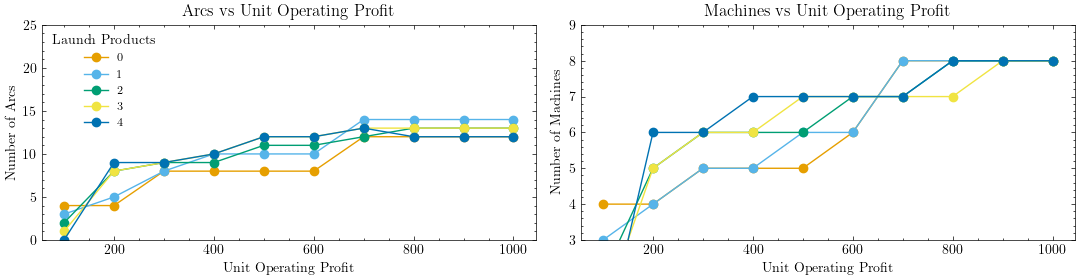

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("analysis_2_launches_vs_net_revenue.csv")

# --- Pivot data ---
pivot_multi = df.pivot_table(index="net_revenue", columns="launch_products", values="multi_profit")
pivot_single = df.pivot_table(index="net_revenue", columns="launch_products", values="single_profit")

# --- Create figure with shared y-axis ---
fig, axs = plt.subplots(1, 2, figsize=(11,3), sharey=True)

# Left panel: Multi-Period
pivot_multi.plot(ax=axs[0], marker="o", linewidth=1, markersize=6)
axs[0].set_title("Multi-Period Objective NPV vs Unit Operating Profit")
axs[0].set_xlabel("Unit Operating Profit")
axs[0].set_ylabel("Objective NPV")
axs[0].set_xticks(pivot_multi.index)
axs[0].set_ylim(0, 1_000_000)
axs[0].yaxis.set_major_formatter(comma_fmt)
axs[0].legend(title="Launch Products", loc="upper left",fontsize="small")

# Right panel: Start-Period
pivot_single.plot(ax=axs[1], marker="o", linewidth=1, markersize=6)
axs[1].set_title("Start-Period Objective NPV vs Unit Operating Profit")
axs[1].set_xlabel("Unit Operating Profit")
axs[1].set_xticks(pivot_single.index)
axs[1].set_ylim(0, 1_000_000)
axs[1].yaxis.set_major_formatter(comma_fmt)
axs[1].legend().remove()
plt.tight_layout()
plt.savefig('launchrev_profit.pdf')
plt.show()


# --- Pivot data ---
pivot_arcs = df.pivot_table(index="net_revenue", columns="launch_products", values="n_arcs_multi")
pivot_machines = df.pivot_table(index="net_revenue", columns="launch_products", values="multi_machines")

# --- Create figure ---
fig, axs = plt.subplots(1, 2, figsize=(11,3))

# Left panel: Arcs
pivot_arcs.plot(ax=axs[0], marker="o", linewidth=1, markersize=6)
axs[0].set_title("Arcs vs Unit Operating Profit")
axs[0].set_xlabel("Unit Operating Profit")
axs[0].set_ylabel("Number of Arcs")
#axs[0].set_xticks(pivot_arcs.index)
axs[0].yaxis.set_major_formatter(comma_fmt)
axs[0].legend(title="Launch Products", loc="best",fontsize="small")
axs[0].set_ylim(0, 25)

# Right panel: Machines
pivot_machines.plot(ax=axs[1], marker="o", linewidth=1, markersize=6)
axs[1].set_title("Machines vs Unit Operating Profit")
axs[1].set_xlabel("Unit Operating Profit")
axs[1].set_ylabel("Number of Machines")
#axs[1].set_xticks(pivot_machines.index)
axs[1].yaxis.set_major_formatter(comma_fmt)
axs[1].legend().remove(); axs[1].set_ylim(3, 9)
plt.tight_layout()
plt.savefig('launchrev_am.pdf')
plt.show()


📊 Analysis 3 — Launches vs Growth Demand Level

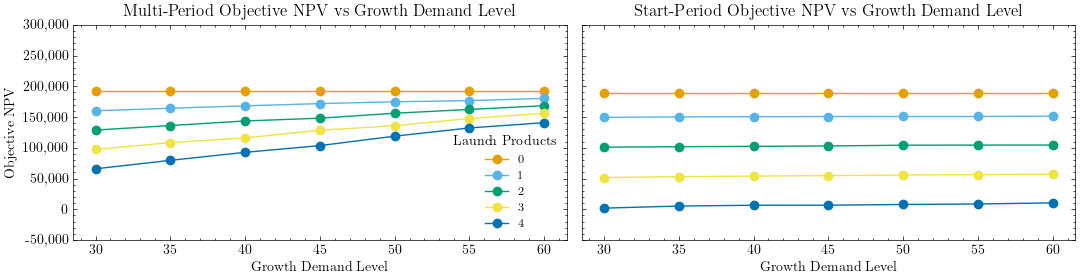

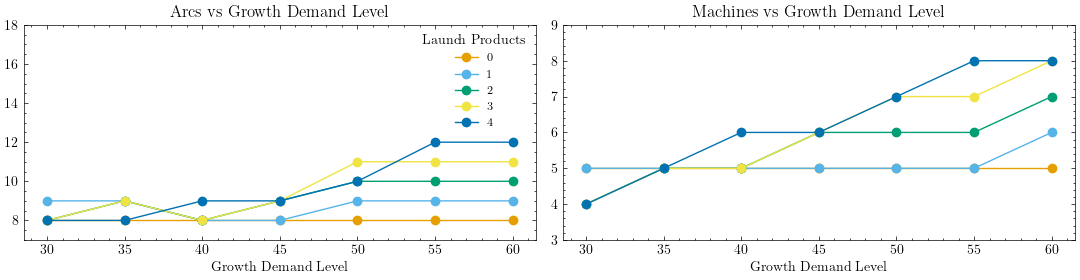

In [7]:
df = pd.read_csv("analysis_3_launches_vs_growth_demand_level.csv")

# Profits
pivot_multi = df.pivot_table(index="growth_demand_level", columns="launch_products", values="multi_profit")
pivot_single = df.pivot_table(index="growth_demand_level", columns="launch_products", values="single_profit")

fig, axs = plt.subplots(1, 2, figsize=(11,3), sharey=True)

pivot_multi.plot(ax=axs[0], marker="o", linewidth=1, markersize=6)
axs[0].set_title("Multi-Period Objective NPV vs Growth Demand Level")
axs[0].set_xlabel("Growth Demand Level"); axs[0].set_ylabel("Objective NPV")
axs[0].yaxis.set_major_formatter(comma_fmt)
axs[0].set_ylim(-50000, 300_000); axs[0].legend(title="Launch Products",fontsize="small")

pivot_single.plot(ax=axs[1], marker="o", linewidth=1, markersize=6)
axs[1].set_title("Start-Period Objective NPV vs Growth Demand Level")
axs[1].set_xlabel("Growth Demand Level")
axs[1].yaxis.set_major_formatter(comma_fmt)
axs[1].set_ylim(-50000, 300_000); axs[1].legend().remove()

plt.tight_layout();
plt.savefig('launchlvl_profit.pdf')
plt.show()

# Arcs & Machines
pivot_arcs = df.pivot_table(index="growth_demand_level", columns="launch_products", values="n_arcs_multi")
pivot_machines = df.pivot_table(index="growth_demand_level", columns="launch_products", values="multi_machines")

fig, axs = plt.subplots(1, 2, figsize=(11,3))
pivot_arcs.plot(ax=axs[0], marker="o"); axs[0].set_title("Arcs vs Growth Demand Level"); axs[0].legend(title="Launch Products",fontsize="small"); axs[0].set_ylim(7, 18);axs[0].set_xlabel("Growth Demand Level")
pivot_machines.plot(ax=axs[1], marker="o"); axs[1].set_title("Machines vs Growth Demand Level"); axs[1].legend().remove();axs[1].set_xlabel("Growth Demand Level"); axs[1].set_ylim(3, 9)
plt.tight_layout();
plt.savefig('launchlvl_am.pdf')
plt.show()


📊 Analysis 4 — Launches vs Growth Slope

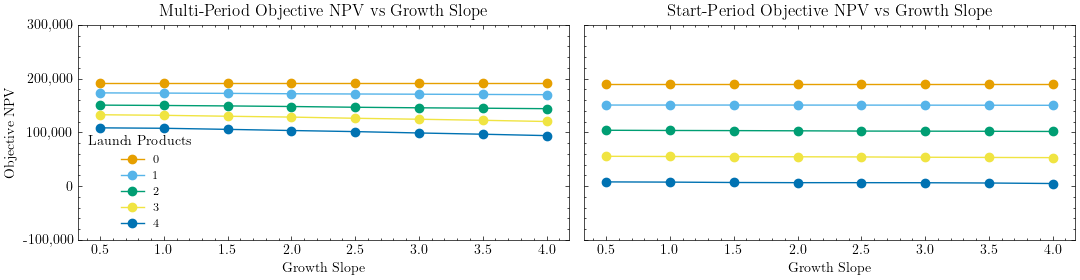

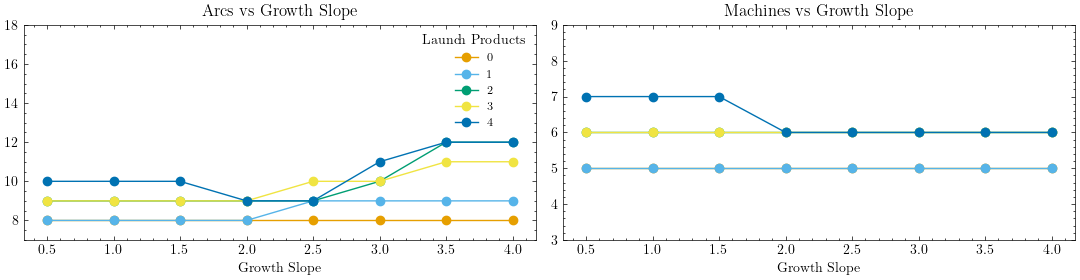

In [9]:
df = pd.read_csv("analysis_4_launches_vs_growth_slope.csv")

# Profits
pivot_multi = df.pivot_table(index="growth_slope", columns="launch_products", values="multi_profit")
pivot_single = df.pivot_table(index="growth_slope", columns="launch_products", values="single_profit")

fig, axs = plt.subplots(1, 2, figsize=(11,3), sharey=True)

pivot_multi.plot(ax=axs[0], marker="o", linewidth=1, markersize=6)
axs[0].set_title("Multi-Period Objective NPV vs Growth Slope")
axs[0].set_xlabel("Growth Slope"); axs[0].set_ylabel("Objective NPV")
axs[0].yaxis.set_major_formatter(comma_fmt)
axs[0].set_ylim(-100000, 300_000); axs[0].legend(title="Launch Products", fontsize="small")

pivot_single.plot(ax=axs[1], marker="o", linewidth=1, markersize=6)
axs[1].set_title("Start-Period Objective NPV vs Growth Slope")
axs[1].set_xlabel("Growth Slope")
axs[1].yaxis.set_major_formatter(comma_fmt)
axs[1].set_ylim(-100000, 300_000); axs[1].legend().remove()

plt.tight_layout();
plt.savefig('launchslpe_profit.pdf')
plt.show()

# Arcs & Machines
pivot_arcs = df.pivot_table(index="growth_slope", columns="launch_products", values="n_arcs_multi")
pivot_machines = df.pivot_table(index="growth_slope", columns="launch_products", values="multi_machines")

fig, axs = plt.subplots(1, 2, figsize=(11,3))
pivot_arcs.plot(ax=axs[0], marker="o"); axs[0].set_title("Arcs vs Growth Slope"); axs[0].legend(title="Launch Products", fontsize="small"); axs[0].set_ylim(7, 18); axs[0].set_xlabel("Growth Slope")
pivot_machines.plot(ax=axs[1], marker="o"); axs[1].set_title("Machines vs Growth Slope"); axs[1].legend().remove(); axs[1].set_xlabel("Growth Slope"); axs[1].set_ylim(3, 9)
plt.tight_layout();
plt.savefig('launchslpe_am.pdf')
plt.show()


📊 Analysis 5 — Launches vs Launch Time

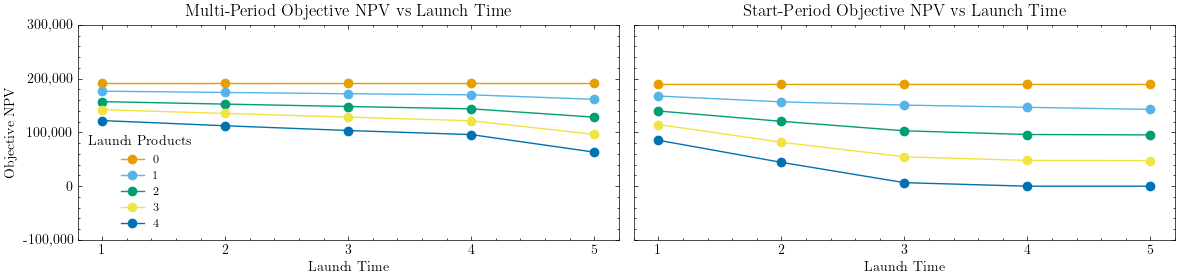

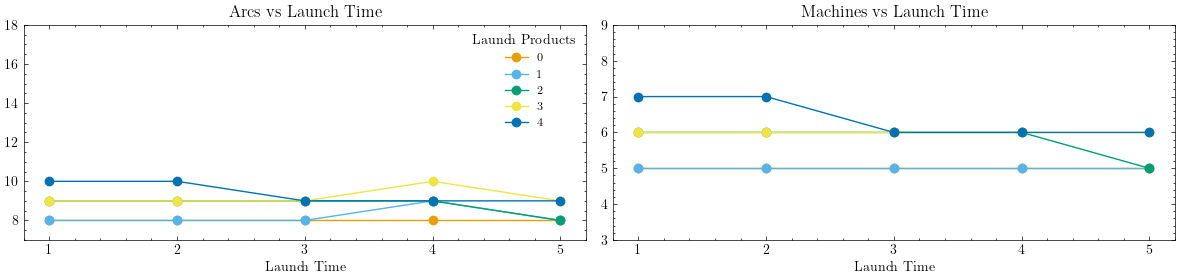

In [11]:
df = pd.read_csv("analysis_5_launches_vs_launch_time.csv")

# Profits
pivot_multi = df.pivot_table(index="launch_time", columns="launch_products", values="multi_profit")
pivot_single = df.pivot_table(index="launch_time", columns="launch_products", values="single_profit")

fig, axs = plt.subplots(1, 2, figsize=(12,3), sharey=True)

pivot_multi.plot(ax=axs[0], marker="o", linewidth=1, markersize=6)
axs[0].set_title("Multi-Period Objective NPV vs Launch Time")
axs[0].set_xlabel("Launch Time"); axs[0].set_ylabel("Objective NPV")
axs[0].yaxis.set_major_formatter(comma_fmt)
axs[0].set_xticks(pivot_multi.index)
axs[0].set_ylim(-100000, 300_000); axs[0].legend(title="Launch Products", fontsize="small")

pivot_single.plot(ax=axs[1], marker="o", linewidth=1, markersize=6)
axs[1].set_title("Start-Period Objective NPV vs Launch Time")
axs[1].set_xlabel("Launch Time")
axs[1].yaxis.set_major_formatter(comma_fmt)
axs[1].set_xticks(pivot_single.index)
axs[1].set_ylim(-100000, 300_000); axs[1].legend().remove()

plt.tight_layout();
plt.savefig('launchtime_profit.pdf')
plt.show()

# Arcs & Machines
pivot_arcs = df.pivot_table(index="launch_time", columns="launch_products", values="n_arcs_multi")
pivot_machines = df.pivot_table(index="launch_time", columns="launch_products", values="multi_machines")

fig, axs = plt.subplots(1, 2, figsize=(12,3))
pivot_arcs.plot(ax=axs[0], marker="o"); axs[0].set_title("Arcs vs Launch Time");
axs[0].set_xticks(pivot_arcs.index); axs[0].legend(title="Launch Products", fontsize="small"); axs[0].set_ylim(7, 18); axs[0].set_xlabel("Launch Time")
pivot_machines.plot(ax=axs[1], marker="o");
axs[1].set_xticks(pivot_machines.index); axs[1].set_title("Machines vs Launch Time"); axs[1].legend().remove(); axs[1].set_xlabel("Launch Time"); axs[1].set_ylim(3, 9)
plt.tight_layout();
plt.savefig('launchtime_am.pdf')
plt.show()


📊 Analysis 6 — Declines vs Competition Time

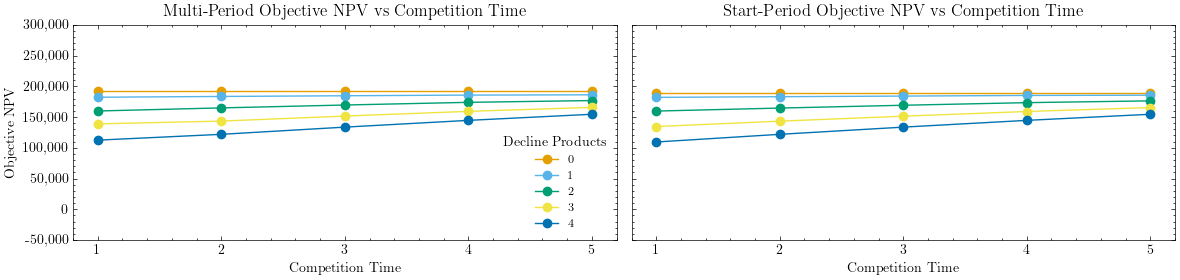

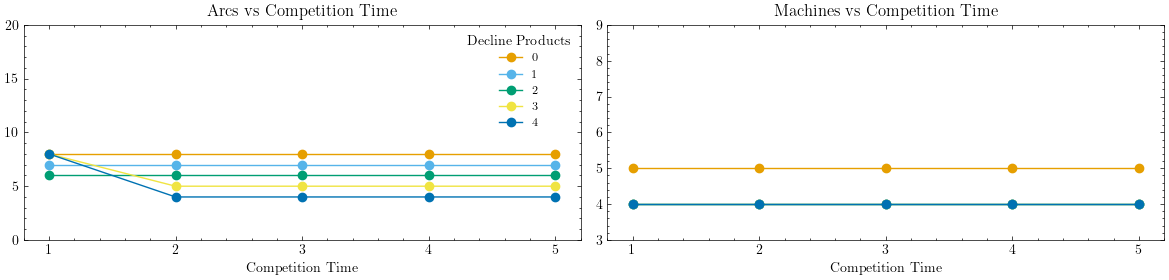

In [12]:
df = pd.read_csv("analysis_6_declines_vs_competition_time.csv")

pivot_multi = df.pivot_table(index="competition_time", columns="decline_products", values="multi_profit")
pivot_single = df.pivot_table(index="competition_time", columns="decline_products", values="single_profit")

fig, axs = plt.subplots(1, 2, figsize=(12,3), sharey=True)

pivot_multi.plot(ax=axs[0], marker="o", linewidth=1, markersize=6)
axs[0].set_title("Multi-Period Objective NPV vs Competition Time")
axs[0].set_xlabel("Competition Time"); axs[0].set_ylabel("Objective NPV")
axs[0].yaxis.set_major_formatter(comma_fmt)
axs[0].set_xticks(pivot_multi.index)
axs[0].set_ylim(-50000, 300_000); axs[0].legend(title="Decline Products", fontsize="small")

pivot_single.plot(ax=axs[1], marker="o", linewidth=1, markersize=6)
axs[1].set_title("Start-Period Objective NPV vs Competition Time")
axs[1].set_xlabel("Competition Time")
axs[1].set_xticks(pivot_single.index)
axs[1].yaxis.set_major_formatter(comma_fmt)
axs[1].set_ylim(-50000, 300_000); axs[1].legend().remove()

plt.tight_layout();
plt.savefig('declinetime_profit.pdf')
plt.show()

# Arcs & Machines
pivot_arcs = df.pivot_table(index="competition_time", columns="decline_products", values="n_arcs_multi")
pivot_machines = df.pivot_table(index="competition_time", columns="decline_products", values="multi_machines")

fig, axs = plt.subplots(1, 2, figsize=(12,3))
pivot_arcs.plot(ax=axs[0], marker="o");
axs[0].set_title("Arcs vs Competition Time");
axs[0].set_xticks(pivot_arcs.index); axs[0].legend(title="Decline Products", fontsize="small"); axs[0].set_ylim(0, 20); axs[0].set_xlabel("Competition Time")
pivot_machines.plot(ax=axs[1], marker="o"); axs[1].set_title("Machines vs Competition Time");
axs[1].set_xticks(pivot_machines.index); axs[1].legend().remove(); axs[1].set_xlabel("Competition Time"); axs[1].set_ylim(3, 9)
plt.tight_layout();
plt.savefig('declinetime_am.pdf')
plt.show()


📊 Analysis 7 — Declines vs Unit Operating Profit

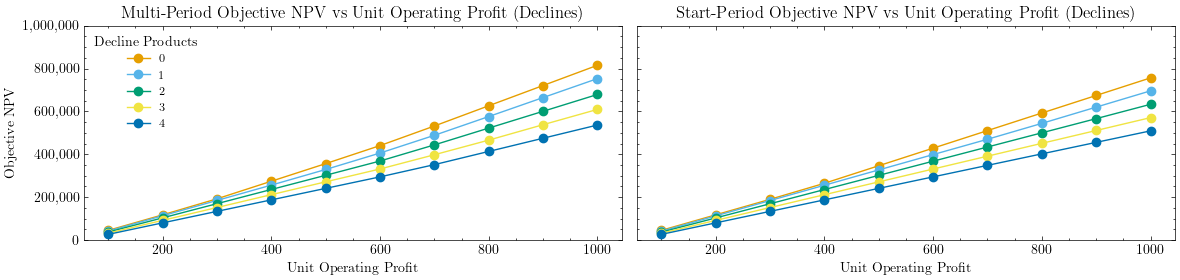

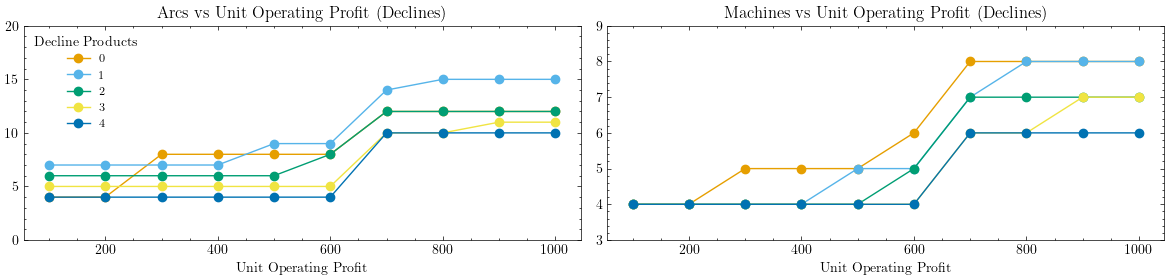

In [13]:
df = pd.read_csv("analysis_7_declines_vs_net_revenue.csv")

pivot_multi = df.pivot_table(index="net_revenue", columns="decline_products", values="multi_profit")
pivot_single = df.pivot_table(index="net_revenue", columns="decline_products", values="single_profit")

fig, axs = plt.subplots(1, 2, figsize=(12,3), sharey=True)
pivot_multi.plot(ax=axs[0], marker="o", linewidth=1, markersize=6)
axs[0].set_title("Multi-Period Objective NPV vs Unit Operating Profit (Declines)")
axs[0].set_xlabel("Unit Operating Profit"); axs[0].set_ylabel("Objective NPV")
axs[0].yaxis.set_major_formatter(comma_fmt)
axs[0].set_ylim(0, 1_000_000); axs[0].legend(title="Decline Products", fontsize="small")

pivot_single.plot(ax=axs[1], marker="o", linewidth=1, markersize=6)
axs[1].set_title("Start-Period Objective NPV vs Unit Operating Profit (Declines)")
axs[1].set_xlabel("Unit Operating Profit")
axs[1].yaxis.set_major_formatter(comma_fmt)
axs[1].set_ylim(0, 1_000_000); axs[1].legend().remove()

plt.tight_layout();
plt.savefig('declineprofit_profit.pdf')
plt.show()

# Arcs & Machines
pivot_arcs = df.pivot_table(index="net_revenue", columns="decline_products", values="n_arcs_multi")
pivot_machines = df.pivot_table(index="net_revenue", columns="decline_products", values="multi_machines")

fig, axs = plt.subplots(1, 2, figsize=(12,3))
pivot_arcs.plot(ax=axs[0], marker="o"); axs[0].set_title("Arcs vs Unit Operating Profit (Declines)"); axs[0].legend(title="Decline Products", fontsize="small"); axs[0].set_ylim(0, 20); axs[0].set_xlabel("Unit Operating Profit")
pivot_machines.plot(ax=axs[1], marker="o"); axs[1].set_title("Machines vs Unit Operating Profit (Declines)"); axs[1].legend().remove(); axs[1].set_xlabel("Unit Operating Profit"); axs[1].set_ylim(3, 9)
plt.tight_layout();
plt.savefig('declineprofit_am.pdf')
plt.show()


📊 Analysis 8 — Declines vs Decline Demand Level

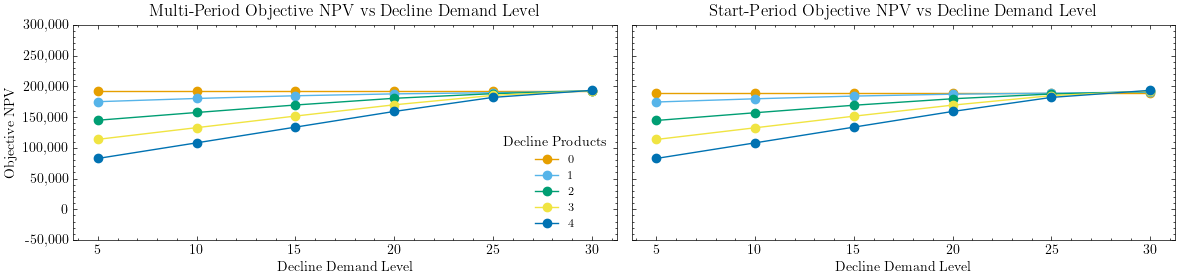

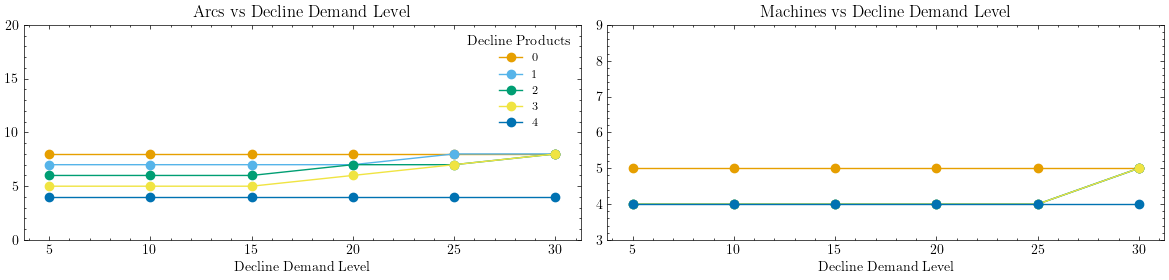

In [15]:
df = pd.read_csv("analysis_8_declines_vs_decline_demand_level.csv")

pivot_multi = df.pivot_table(index="decline_demand_level", columns="decline_products", values="multi_profit")
pivot_single = df.pivot_table(index="decline_demand_level", columns="decline_products", values="single_profit")

fig, axs = plt.subplots(1, 2, figsize=(12,3), sharey=True)

pivot_multi.plot(ax=axs[0], marker="o", linewidth=1, markersize=6)
axs[0].set_title("Multi-Period Objective NPV vs Decline Demand Level")
axs[0].set_xlabel("Decline Demand Level"); axs[0].set_ylabel("Objective NPV")
axs[0].yaxis.set_major_formatter(comma_fmt)
axs[0].set_ylim(-50000, 300_000); axs[0].legend(title="Decline Products", fontsize="small")

pivot_single.plot(ax=axs[1], marker="o", linewidth=1, markersize=6)
axs[1].set_title("Start-Period Objective NPV vs Decline Demand Level")
axs[1].set_xlabel("Decline Demand Level")
axs[1].yaxis.set_major_formatter(comma_fmt)
axs[1].set_ylim(-50000, 300_000); axs[1].legend().remove()

plt.tight_layout();
plt.savefig('declinelvl_profit.pdf')
plt.show()

# Arcs & Machines
pivot_arcs = df.pivot_table(index="decline_demand_level", columns="decline_products", values="n_arcs_multi")
pivot_machines = df.pivot_table(index="decline_demand_level", columns="decline_products", values="multi_machines")

fig, axs = plt.subplots(1, 2, figsize=(12,3))
pivot_arcs.plot(ax=axs[0], marker="o"); axs[0].set_title("Arcs vs Decline Demand Level"); axs[0].legend(title="Decline Products", fontsize="small"); axs[0].set_ylim(0, 20); axs[0].set_xlabel("Decline Demand Level")
pivot_machines.plot(ax=axs[1], marker="o"); axs[1].set_title("Machines vs Decline Demand Level"); axs[1].legend().remove(); axs[1].set_xlabel("Decline Demand Level"); axs[1].set_ylim(3, 9)
plt.tight_layout();
plt.savefig('declinelvl_am.pdf')
plt.show()


📊 Analysis 9 — Declines vs Decline Slope

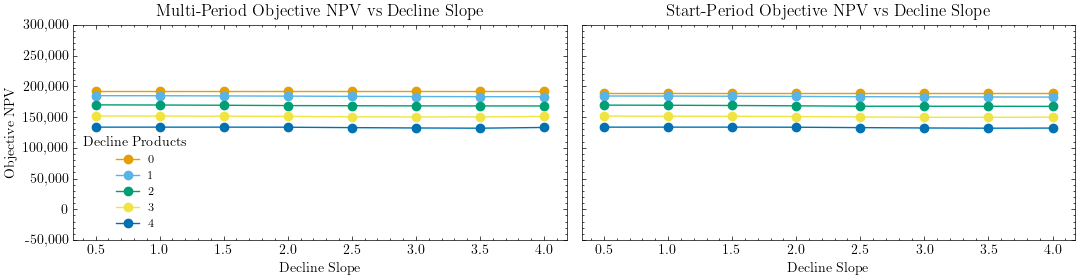

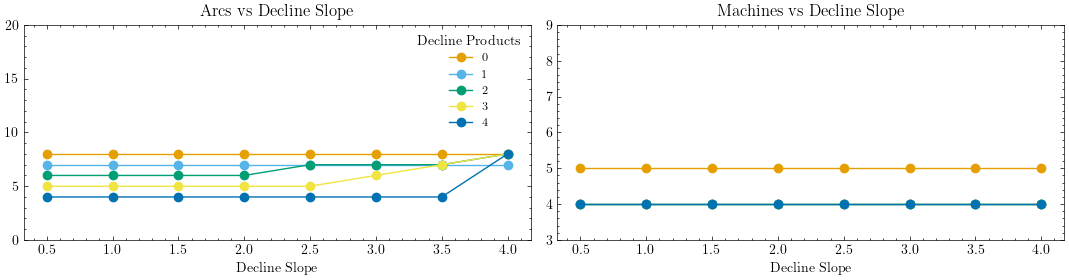

In [16]:
df = pd.read_csv("analysis_9_declines_vs_decline_slope.csv")

pivot_multi = df.pivot_table(index="decline_slope", columns="decline_products", values="multi_profit")
pivot_single = df.pivot_table(index="decline_slope", columns="decline_products", values="single_profit")

fig, axs = plt.subplots(1, 2, figsize=(11,3), sharey=True)

pivot_multi.plot(ax=axs[0], marker="o", linewidth=1, markersize=6)
axs[0].set_title("Multi-Period Objective NPV vs Decline Slope")
axs[0].set_xlabel("Decline Slope"); axs[0].set_ylabel("Objective NPV")
axs[0].yaxis.set_major_formatter(comma_fmt)
axs[0].set_ylim(-50000, 300_000); axs[0].legend(title="Decline Products", fontsize="small")

pivot_single.plot(ax=axs[1], marker="o", linewidth=1, markersize=6)
axs[1].set_title("Start-Period Objective NPV vs Decline Slope")
axs[1].set_xlabel("Decline Slope")
axs[1].yaxis.set_major_formatter(comma_fmt)
axs[1].set_ylim(-50000, 300_000); axs[1].legend().remove()

plt.tight_layout();
plt.savefig('declineslope_profit.pdf')
plt.show()

# Arcs & Machines
pivot_arcs = df.pivot_table(index="decline_slope", columns="decline_products", values="n_arcs_multi")
pivot_machines = df.pivot_table(index="decline_slope", columns="decline_products", values="multi_machines")

fig, axs = plt.subplots(1, 2, figsize=(11,3))
pivot_arcs.plot(ax=axs[0], marker="o"); axs[0].set_title("Arcs vs Decline Slope"); axs[0].legend(title="Decline Products", fontsize="small"); axs[0].set_ylim(0, 20); axs[0].set_xlabel("Decline Slope")
pivot_machines.plot(ax=axs[1], marker="o"); axs[1].set_title("Machines vs Decline Slope"); axs[1].legend().remove(); axs[1].set_xlabel("Decline Slope"); axs[1].set_ylim(3, 9)
plt.tight_layout();
plt.savefig('declineslope_am.pdf')
plt.show()


📊 Analysis 10 — Probability of Launch

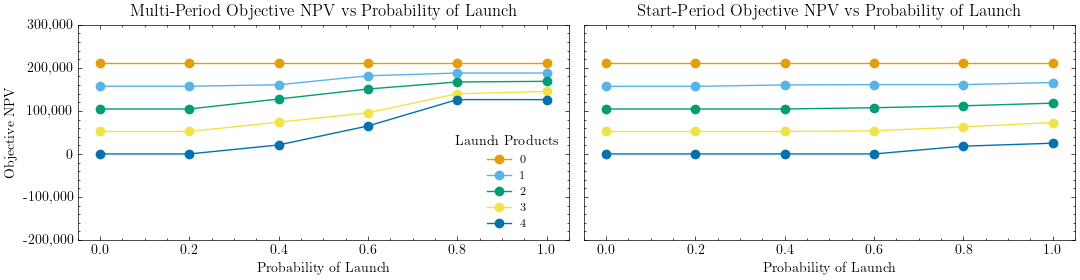

In [17]:
df = pd.read_csv("analysis_10_ofat_probability_launch.csv")

pivot_multi = df.pivot_table(index="probability_launch", columns="launch_products", values="multi_profit")
pivot_single = df.pivot_table(index="probability_launch", columns="launch_products", values="single_profit")

fig, axs = plt.subplots(1, 2, figsize=(11,3), sharey=True)

pivot_multi.plot(ax=axs[0], marker="o", linewidth=1, markersize=6)
axs[0].set_title("Multi-Period Objective NPV vs Probability of Launch")
axs[0].set_xlabel("Probability of Launch"); axs[0].set_ylabel("Objective NPV")
axs[0].yaxis.set_major_formatter(comma_fmt)
axs[0].set_ylim(-200000, 300_000); axs[0].legend(title="Launch Products", fontsize="small")

pivot_single.plot(ax=axs[1], marker="o", linewidth=1, markersize=6)
axs[1].set_title("Start-Period Objective NPV vs Probability of Launch")
axs[1].set_xlabel("Probability of Launch")
axs[1].yaxis.set_major_formatter(comma_fmt)
axs[1].set_ylim(-200000, 300_000); axs[1].legend().remove()

plt.tight_layout();
plt.savefig('launchprob_profit.pdf')
plt.show()


Analysis 12 (Availability × Base Slope)

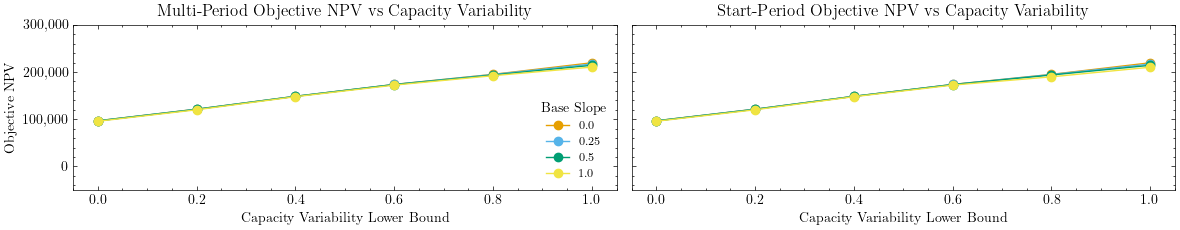

In [18]:
df12 = pd.read_csv("analysis_12_established_availability_slope.csv")

pivot_multi = df12.pivot_table(
    index="availability",
    columns="base_slope",
    values="multi_profit"
)
pivot_single = df12.pivot_table(
    index="availability",
    columns="base_slope",
    values="single_profit"
)

fig, axs = plt.subplots(1, 2, figsize=(12,2.5), sharey=True)

# Multi-Period
pivot_multi.plot(ax=axs[0], marker="o", linewidth=1, markersize=6)
axs[0].set_title("Multi-Period Objective NPV vs Capacity Variability")
axs[0].set_xlabel("Capacity Variability Lower Bound")
axs[0].set_ylabel("Objective NPV")
axs[0].yaxis.set_major_formatter(comma_fmt)
axs[0].set_ylim(-50000, 300_000)
axs[0].legend(title="Base Slope", fontsize="small")

# Start-Period
pivot_single.plot(ax=axs[1], marker="o", linewidth=1, markersize=6)
axs[1].set_title("Start-Period Objective NPV vs Capacity Variability")
axs[1].set_xlabel("Capacity Variability Lower Bound")
axs[1].yaxis.set_major_formatter(comma_fmt)
axs[1].set_ylim(-50000, 300_000)
axs[1].legend().remove()

plt.tight_layout();
plt.savefig('avail_profit.pdf')
plt.show()


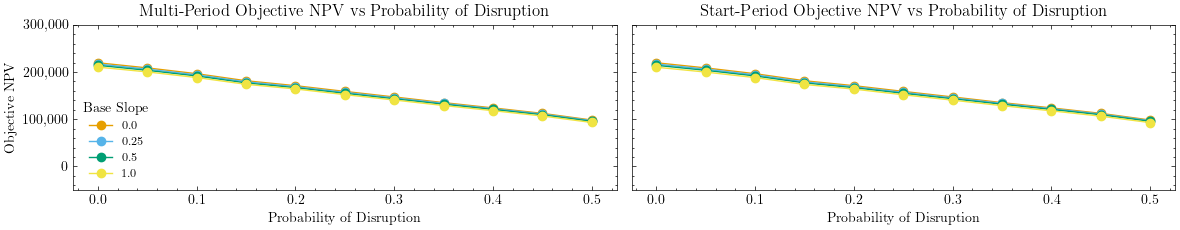

In [19]:
df13 = pd.read_csv('analysis_13_probdisruption_base_slope.csv')

pivot_multi = df13.pivot_table(
    index="prob_disruption",
    columns="base_slope",
    values="multi_profit"
)
pivot_single = df13.pivot_table(
    index="prob_disruption",
    columns="base_slope",
    values="single_profit"
)

fig, axs = plt.subplots(1, 2, figsize=(12,2.5), sharey=True)

# Multi-Period
pivot_multi.plot(ax=axs[0], marker="o", linewidth=1, markersize=6)
axs[0].set_title("Multi-Period Objective NPV vs Probability of Disruption")
axs[0].set_xlabel("Probability of Disruption")
axs[0].set_ylabel("Objective NPV")
axs[0].yaxis.set_major_formatter(comma_fmt)
axs[0].set_ylim(-50000, 300_000)
axs[0].legend(title="Base Slope", fontsize="small")

# Start-Period
pivot_single.plot(ax=axs[1], marker="o", linewidth=1, markersize=6)
axs[1].set_title("Start-Period Objective NPV vs Probability of Disruption")
axs[1].set_xlabel("Probability of Disruption")
axs[1].yaxis.set_major_formatter(comma_fmt)
axs[1].set_ylim(-50000, 300_000)
axs[1].legend().remove()

plt.tight_layout();
plt.savefig('avail_disrupt.pdf')
plt.show()


0) Imports, palette, helpers

In [20]:
# --- Imports
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from sklearn.preprocessing import MinMaxScaler

# --- Okabe–Ito color-blind friendly palette (8 colors)
OKABE_ITO = [
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#009E73",  # bluish green
    "#F0E442",  # yellow
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#CC79A7",  # reddish purple
    "#000000",  # black
]
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=OKABE_ITO)

# --- Formatting helpers
def comma_fmt(x, pos=None):
    # Robust thousands formatter for ints/floats
    try:
        return f"{x:,.0f}"
    except Exception:
        return str(x)

fmt_comma = FuncFormatter(comma_fmt)

def coef_table_with_ci(model):
    """Return tidy coefficient table with 95% CI."""
    out = model.params.to_frame("coef")
    out["std_err"] = model.bse
    ci = model.conf_int()
    out["ci_low"] = ci[0]
    out["ci_high"] = ci[1]
    out["t"] = model.tvalues
    out["p"] = model.pvalues
    return out

def partial_eta_squared(anova_tbl):
    """Compute partial eta-squared from Type II/III ANOVA table."""
    ss_resid = float(anova_tbl.loc["Residual", "sum_sq"])
    pes = anova_tbl["sum_sq"] / (anova_tbl["sum_sq"] + ss_resid)
    anova_tbl = anova_tbl.copy()
    anova_tbl["partial_eta_sq"] = pes
    return anova_tbl


1) Launches — build data & regressions

In [27]:
# --- Load and stitch the 4 "launches" sensitivity tables
df1 = pd.read_csv('analysis_4_launches_vs_growth_slope.csv')
df2 = pd.read_csv('analysis_5_launches_vs_launch_time.csv')
df3 = pd.read_csv('analysis_2_launches_vs_net_revenue.csv')
df4 = pd.read_csv('analysis_3_launches_vs_growth_demand_level.csv')

# Fill baseline controls (so concatenation aligns columns)
df1['growth_demand_level'] = 45; df1['launch_time'] = 3; df1['net_revenue'] = 300
df1['decline_slope'] = 0.5; df1['decline_demand_level'] = 15; df1['competition_time'] = 3

df2['growth_demand_level'] = 45; df2['growth_slope'] = 0.5; df2['net_revenue'] = 300
df2['decline_slope'] = 0.5; df2['decline_demand_level'] = 15; df2['competition_time'] = 3

df3['growth_demand_level'] = 45; df3['growth_slope'] = 0.5; df3['launch_time'] = 3
df3['decline_slope'] = 0.5; df3['decline_demand_level'] = 15; df3['competition_time'] = 3

df4['growth_slope'] = 0.5; df4['launch_time'] = 3; df4['net_revenue'] = 300
df4['decline_slope'] = 0.5; df4['decline_demand_level'] = 15; df4['competition_time'] = 3

# Combine
dfL = pd.concat([df1, df2, df3, df4], ignore_index=True)

# Targets
dfL['VMPSP'] = dfL['multi_profit'] - dfL['single_profit']
dfL['VMPLC'] = dfL['multi_profit'] - dfL['long_profit']

# Friendly column names (Title Case)
dfL.columns = [c.replace('_', ' ').title() if not c.isupper() else c for c in dfL.columns]

# Consistent arc/machine columns
dfL['Number of Arcs Multi-Period']   = dfL['N Arcs Multi']
dfL['Number of Arcs Start-Period']   = dfL['N Arcs Single']
dfL['Number of Arcs Long-Chain']     = dfL['N Arcs Long']
dfL['Number Of Machines Multi-Period'] = dfL['Multi Machines']
dfL['Number Of Machines Start-Period'] = dfL['Single Machines']
dfL['Number Of Machines Long-Chain']   = dfL['N Machines Long']
dfL['Decline Time'] = dfL['Competition Time']
dfL['Unit Operating Profit'] = dfL['Net Revenue']

# Drop extras and save
#drop_cols = ['Percent Vmpsp','Percent Vmplc','N Arcs Multi','N Arcs Single','N Arcs Long',
#             'Multi Machines','Single Machines','N Machines Long','Competition Time']
#dfL = dfL.drop(columns=[c for c in drop_cols if c in dfL.columns])
dfL.to_csv("combined_launches.csv", index=False)

# --- Robust OLS on normalized continuous covariates + categorical # Launch Products
df = pd.read_csv("combined_launches.csv")

# Normalize only continuous regressors (keep target unscaled)
to_norm = ['Unit Operating Profit', 'Launch Time', 'Growth Slope', 'Growth Demand Level']
scaler = MinMaxScaler()
df[to_norm] = scaler.fit_transform(df[to_norm])

# Categorical: Launch Products (0 baseline)
model_L = smf.ols(
    "VMPSP ~ Q('Launch Time') + Q('Growth Slope') + Q('Growth Demand Level')"
    " + C(Q('Launch Products'), Treatment(reference=0))",
    data=df
).fit()

print(model_L.summary())

# Categorical: Launch Products (0 baseline)
model_L = smf.ols(
    "VMPSP ~ Q('Unit Operating Profit')+ Q('Launch Time') + Q('Growth Slope') + Q('Growth Demand Level')"
    " + C(Q('Launch Products'), Treatment(reference=0))",
    data=df
).fit()

print(model_L.summary())


# # --- Coefficient table (sorted, with 95% CI)
# coefL = coef_table_with_ci(model_L).sort_index()
# coefL.to_csv("launches_regression_coefs.csv")
# coefL.head(20)

model_L = smf.ols(
    "Q('N Arcs Multi') ~ Q('Launch Time') + Q('Growth Slope') + Q('Growth Demand Level')"
    " + C(Q('Launch Products'), Treatment(reference=0))",
    data=df
).fit()

print(model_L.summary())


model_L = smf.ols(
    "Q('Multi Machines') ~ Q('Launch Time') + Q('Growth Slope') + Q('Growth Demand Level')"
    " + C(Q('Launch Products'), Treatment(reference=0))",
    data=df
).fit()

print(model_L.summary())

                            OLS Regression Results                            
Dep. Variable:                  VMPSP   R-squared:                       0.477
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     18.53
Date:                Sat, 22 Aug 2026   Prob (F-statistic):           2.18e-17
Time:                        19:13:51   Log-Likelihood:                -1799.5
No. Observations:                 150   AIC:                             3615.
Df Residuals:                     142   BIC:                             3639.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                                           coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------

In [22]:
dfL.columns

Index(['Analysis', 'Analysis Name', 'Analysis Task Index', 'Run Id',
       'Established Products', 'Launch Products', 'Decline Products',
       'Growth Slope', 'Availability', 'Probability Launch',
       'N Scenarios Sampled', 'Seed', 'Capacity Seed',
       'Evaluation Include No Launch', 'Solver Threads', 'Time Limit Multi',
       'Time Limit Single', 'Time Limit Long', 'Time Limit Evaluation',
       'Multi Profit', 'Single Profit', 'Long Profit', 'N Arcs Multi',
       'N Arcs Single', 'N Arcs Long', 'Multi Machines', 'Single Machines',
       'N Machines Long', 'VMPSP', 'VMPLC', 'Percent Vmpsp', 'Percent Vmplc',
       'Planning Scenarios', 'Evaluation Scenarios', 'Status',
       'Runtime Seconds', 'Error Type', 'Error Message', 'Growth Demand Level',
       'Launch Time', 'Net Revenue', 'Decline Slope', 'Decline Demand Level',
       'Competition Time', 'Number of Arcs Multi-Period',
       'Number of Arcs Start-Period', 'Number of Arcs Long-Chain',
       'Number Of Machine

2) Declines — build data & regressions

In [28]:
# --- Load and stitch the 4 "declines" sensitivity tables
df5 = pd.read_csv('analysis_6_declines_vs_competition_time.csv')
df6 = pd.read_csv('analysis_7_declines_vs_net_revenue.csv')
df7 = pd.read_csv('analysis_8_declines_vs_decline_demand_level.csv')
df8 = pd.read_csv('analysis_9_declines_vs_decline_slope.csv')

# Fill baseline controls
df5['growth_demand_level'] = 45; df5['growth_slope'] = 0.5; df5['launch_time'] = 3
df5['net_revenue'] = 300; df5['decline_slope'] = 0.5; df5['decline_demand_level'] = 15

df6['growth_demand_level'] = 45; df6['growth_slope'] = 0.5; df6['launch_time'] = 3
df6['decline_slope'] = 0.5; df6['decline_demand_level'] = 15; df6['competition_time'] = 3

df7['growth_demand_level'] = 45; df7['growth_slope'] = 0.5; df7['launch_time'] = 3
df7['net_revenue'] = 300; df7['decline_slope'] = 0.5; df7['competition_time'] = 3

df8['growth_demand_level'] = 45; df8['growth_slope'] = 0.5; df8['launch_time'] = 3
df8['net_revenue'] = 300; df8['decline_demand_level'] = 15; df8['competition_time'] = 3

# Combine
dfD = pd.concat([df5, df6, df7, df8], ignore_index=True)

# Targets
dfD['VMPSP'] = dfD['multi_profit'] - dfD['single_profit']
dfD['VMPLC'] = dfD['multi_profit'] - dfD['long_profit']

# Friendly names
dfD.columns = [c.replace('_', ' ').title() if not c.isupper() else c for c in dfD.columns]

# Consistent arc/machine columns
dfD['Number of Arcs Multi-Period']   = dfD['N Arcs Multi']
dfD['Number of Arcs Start-Period']   = dfD['N Arcs Single']
dfD['Number of Arcs Long-Chain']     = dfD['N Arcs Long']
dfD['Number Of Machines Multi-Period'] = dfD['Multi Machines']
dfD['Number Of Machines Start-Period'] = dfD['Single Machines']
dfD['Number Of Machines Long-Chain']   = dfD['N Machines Long']
dfD['Decline Time'] = dfD['Competition Time']
dfD['Unit Operating Profit'] = dfD['Net Revenue']
# Drop extras and save
# drop_cols = ['Percent Vmpsp','Percent Vmplc','N Arcs Multi','N Arcs Single','N Arcs Long',
#              'Multi Machines','Single Machines','N Machines Long','Competition Time']
# dfD = dfD.drop(columns=[c for c in drop_cols if c in dfD.columns])
dfD.to_csv("combined_declines.csv", index=False)

# --- Robust OLS on normalized continuous covariates + categorical # Decline Products
df = pd.read_csv("combined_declines.csv")

to_norm = ['Unit Operating Profit', 'Decline Time', 'Decline Slope', 'Decline Demand Level']
scaler = MinMaxScaler()
df[to_norm] = scaler.fit_transform(df[to_norm])

# Categorical: Decline Products (0 baseline)
model_D = smf.ols(
    "VMPSP ~ Q('Unit Operating Profit')+ Q('Decline Time') + Q('Decline Slope') + Q('Decline Demand Level')"
    " + C(Q('Decline Products'), Treatment(reference=0))",
    data=df
).fit(cov_type='HC1')

print(model_D.summary())

# # --- Coefficient table (sorted, with 95% CI)
# coefD = coef_table_with_ci(model_D).sort_index()
# coefD.to_csv("declines_regression_coefs.csv")
# coefD.head(20)

model_D = smf.ols(
    "Q('N Arcs Multi') ~ Q('Unit Operating Profit')+ Q('Decline Time') + Q('Decline Slope') + Q('Decline Demand Level')"
    " + C(Q('Decline Products'), Treatment(reference=0))",
    data=df
).fit()

print(model_D.summary())

model_D = smf.ols(
    "Q('N Arcs Multi') ~ Q('Decline Time') + Q('Decline Slope') + Q('Decline Demand Level')"
    " + C(Q('Decline Products'), Treatment(reference=0))",
    data=df
).fit()

print(model_D.summary())

model_D = smf.ols(
    "Q('Multi Machines') ~  Q('Unit Operating Profit')+Q('Decline Time') + Q('Decline Slope') + Q('Decline Demand Level')"
    " + C(Q('Decline Products'), Treatment(reference=0))",
    data=df
).fit()

print(model_D.summary())



                            OLS Regression Results                            
Dep. Variable:                  VMPSP   R-squared:                       0.778
Model:                            OLS   Adj. R-squared:                  0.765
Method:                 Least Squares   F-statistic:                     14.83
Date:                Sat, 22 Aug 2026   Prob (F-statistic):           1.83e-15
Time:                        20:30:20   Log-Likelihood:                -1450.1
No. Observations:                 145   AIC:                             2918.
Df Residuals:                     136   BIC:                             2945.
Df Model:                           8                                         
Covariance Type:                  HC1                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------

3) Mix analysis (v2, E4_L0_C0 baseline)

In [39]:
# --- Mix regression (all-categorical controls)
df = pd.read_csv("analysis_11_factorial_design.csv")
df["VMPSP"] = df["multi_profit"] - df["single_profit"]
df.rename(columns={'established_products': 'mature_products'}, inplace=True)
df.rename(columns={'established_demand': 'mature_demand'}, inplace=True)
df.rename(columns={'compete_demand': 'decline_demand'}, inplace=True)
df.rename(columns={'profit_established': 'mature_profit'}, inplace=True)
df.rename(columns={'profit_compete': 'profit_decline'}, inplace=True)

# Mix factor with explicit order (baseline E4_L0_C0)
mix_order = [
    'M4_L0_D0', 'M3_L1_D0', 'M2_L2_D0', 'M1_L3_D0', 'M0_L4_D0', 
    'M3_L0_D1', 'M2_L1_D1', 'M1_L2_D1', 'M0_L3_D1', 
    'M2_L0_D2', 'M1_L1_D2', 'M0_L2_D2', 
    'M1_L0_D3', 'M0_L1_D3', 
    'M0_L0_D4'
]
df["mix"] = df.apply(
    lambda r: f"M{int(r['mature_products'])}_L{int(r['launch_products'])}_D{int(r['decline_products'])}",
    axis=1
)
df["mix"] = pd.Categorical(df["mix"], categories=mix_order)

# Two-level factors as categorical with explicit levels
two_level = {
    "mature_demand": [15, 30],
    "launch_demand":      [30, 60],
    "decline_demand":     [10, 25],
    "mature_profit": [300, 600],
    "profit_launch":      [300, 600],
    "profit_decline":     [300, 600],
    "probability_launch": [0.5, 0.75],
}
for col, levs in two_level.items():
    df[col] = pd.Categorical(df[col], categories=levs)

# All categorical regression (HC1 robust)
factors = ["mix"] + list(two_level.keys())
formula = "VMPSP ~ " + " + ".join([f"C({f})" for f in factors])
model_mix = smf.ols(formula=formula, data=df).fit(cov_type="HC1")
print(model_mix.summary())

# --- Pull just the mix coefficients (relative to E4_L0_C0)
coefM = coef_table_with_ci(model_mix)
mix_mask = coefM.index.str.startswith("C(mix)[T.")
mix_coef = coefM.loc[mix_mask].copy()

# Order bars by the supplied mix_order sequence
mix_coef["mix_label"] = mix_coef.index.str.replace("C(mix)[T.","", regex=False).str.rstrip("]")
mix_coef = mix_coef.set_index("mix_label").reindex(mix_order[1:])  # omit baseline

# # Plot mix effects (95% CI)
# fig, ax = plt.subplots(figsize=(11,4))
# ax.barh(mix_coef.index, mix_coef['coef'],
#         xerr=[mix_coef['coef']-mix_coef['ci_low'], mix_coef['ci_high']-mix_coef['coef']],
#         align='center', alpha=0.9)
# ax.axvline(0, color='k', lw=1)
# ax.set_title("Product Mix effects on VMPSP (baseline = E4_L0_C0)")
# ax.set_xlabel("Coefficient ( VMPSP)")
# ax.xaxis.set_major_formatter(fmt_comma)
# plt.tight_layout(); plt.show()


                            OLS Regression Results                            
Dep. Variable:                  VMPSP   R-squared:                       0.632
Model:                            OLS   Adj. R-squared:                  0.628
Method:                 Least Squares   F-statistic:                     180.2
Date:                Sat, 22 Aug 2026   Prob (F-statistic):               0.00
Time:                        20:44:37   Log-Likelihood:                -21654.
No. Observations:                1920   AIC:                         4.335e+04
Df Residuals:                    1898   BIC:                         4.347e+04
Df Model:                          21                                         
Covariance Type:                  HC1                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

4) Analysis 11 — ANOVA (Type II) + partial η² plots

<>:50: SyntaxWarning: invalid escape sequence '\e'
<>:51: SyntaxWarning: invalid escape sequence '\e'
<>:78: SyntaxWarning: invalid escape sequence '\e'
<>:79: SyntaxWarning: invalid escape sequence '\e'
<>:50: SyntaxWarning: invalid escape sequence '\e'
<>:51: SyntaxWarning: invalid escape sequence '\e'
<>:78: SyntaxWarning: invalid escape sequence '\e'
<>:79: SyntaxWarning: invalid escape sequence '\e'
/var/folders/sj/st6tx4490j9cw4yh3mw2mcyh0000gp/T/ipykernel_94653/2414010361.py:50: SyntaxWarning: invalid escape sequence '\e'
  ax.set_title("Analysis 11 — Main effects (partial $\eta^2$)")
/var/folders/sj/st6tx4490j9cw4yh3mw2mcyh0000gp/T/ipykernel_94653/2414010361.py:51: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel("partial $\eta^2$")
/var/folders/sj/st6tx4490j9cw4yh3mw2mcyh0000gp/T/ipykernel_94653/2414010361.py:78: SyntaxWarning: invalid escape sequence '\e'
  ax.set_title(f"Analysis 11 — Top {topk} interactions (partial $\eta^2$)")
/var/folders/sj/st6tx4490j9cw4yh3mw

,sum_sq,df,F,PR(>F),partial_eta_sq
C(mix),8.867449e+11,14.0,171.037586,1.482197e-323,0.557836
C(mature_demand),6.007850e+10,1.0,162.233293,1.019590e-35,0.078745
C(launch_demand),5.850712e+10,1.0,157.990009,7.301281e-35,0.076844
C(decline_demand),1.619781e+10,1.0,43.739853,4.861655e-11,0.022526
C(mature_profit),4.670950e+09,1.0,12.613224,3.923687e-04,0.006602
C(profit_launch),1.748393e+11,1.0,472.128158,1.139755e-93,0.199199
C(profit_decline),5.775107e+09,1.0,15.594842,8.133368e-05,0.008150
C(probability_launch),2.008169e+09,1.0,5.422771,1.998033e-02,0.002849
Residual,7.028705e+11,1898.0,NaN,NaN,0.500000


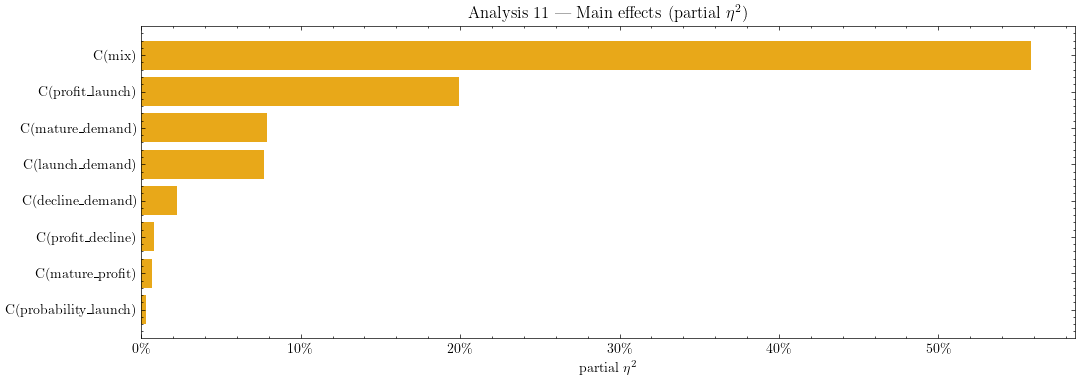

,sum_sq,df,F,PR(>F),partial_eta_sq
C(mix),8.867449e+11,14.0,188.874843,0.000000e+00,0.589412
C(mature_demand),6.007850e+10,1.0,179.152363,4.656426e-39,0.088639
C(launch_demand),5.850712e+10,1.0,174.466554,3.996106e-38,0.086521
C(decline_demand),1.619781e+10,1.0,48.301417,5.053612e-12,0.025552
C(mature_profit),4.670950e+09,1.0,13.928639,1.956427e-04,0.007505
C(profit_launch),1.748393e+11,1.0,521.365705,8.060500e-102,0.220603
C(profit_decline),5.775107e+09,1.0,17.221205,3.478636e-05,0.009263
C(probability_launch),2.008169e+09,1.0,5.988303,1.449390e-02,0.003240
C(mature_demand):C(launch_demand),1.627212e+09,1.0,4.852300,2.773275e-02,0.002627
C(mature_demand):C(decline_demand),1.905702e+09,1.0,5.682747,1.723328e-02,0.003076


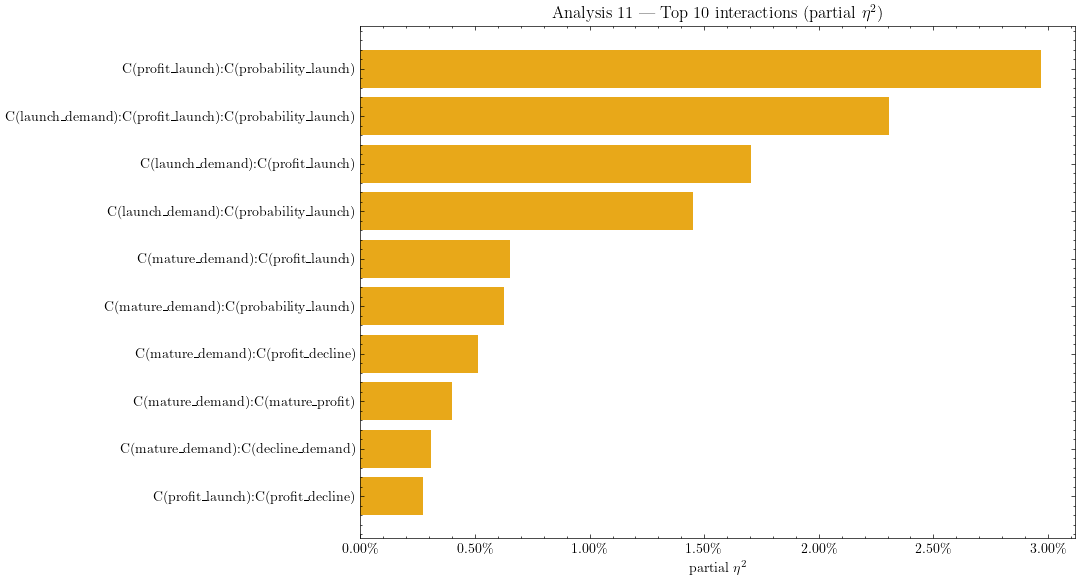

In [41]:
# --- ANOVA main effects and interactions (v2)
df = pd.read_csv("analysis_11_factorial_design.csv")
df["VMPSP"] = df["multi_profit"] - df["single_profit"]
df.rename(columns={'established_products': 'mature_products'}, inplace=True)
df.rename(columns={'established_demand': 'mature_demand'}, inplace=True)
df.rename(columns={'compete_demand': 'decline_demand'}, inplace=True)
df.rename(columns={'profit_established': 'mature_profit'}, inplace=True)
df.rename(columns={'profit_compete': 'profit_decline'}, inplace=True)

# Mix factor with explicit order (baseline E4_L0_C0)
mix_order = [
    'M4_L0_D0', 'M3_L1_D0', 'M2_L2_D0', 'M1_L3_D0', 'M0_L4_D0', 
    'M3_L0_D1', 'M2_L1_D1', 'M1_L2_D1', 'M0_L3_D1', 
    'M2_L0_D2', 'M1_L1_D2', 'M0_L2_D2', 
    'M1_L0_D3', 'M0_L1_D3', 
    'M0_L0_D4'
]
df["mix"] = df.apply(
    lambda r: f"M{int(r['mature_products'])}_L{int(r['launch_products'])}_D{int(r['decline_products'])}",
    axis=1
)
df["mix"] = pd.Categorical(df["mix"], categories=mix_order)

# Two-level factors as categorical with explicit levels
two_level = {
    "mature_demand": [15, 30],
    "launch_demand":      [30, 60],
    "decline_demand":     [10, 25],
    "mature_profit": [300, 600],
    "profit_launch":      [300, 600],
    "profit_decline":     [300, 600],
    "probability_launch": [0.5, 0.75],
}
for col, levs in two_level.items():
    df[col] = pd.Categorical(df[col], categories=levs)

# --- Main effects model
main_terms = "C(mix) + " + " + ".join([f"C({f})" for f in two_level.keys()])
model_main = smf.ols(f"VMPSP ~ {main_terms}", data=df).fit()
anova_main = anova_lm(model_main, typ=2)
anova_main = partial_eta_squared(anova_main)
display(anova_main)

# Plot partial eta-squared (main effects only, excluding residual)
main_plot = anova_main.drop(index="Residual").copy()
main_plot = main_plot.sort_values("partial_eta_sq", ascending=True)

fig, ax = plt.subplots(figsize=(11,4))
ax.barh(main_plot.index, main_plot["partial_eta_sq"], alpha=0.9)
ax.set_title("Analysis 11 — Main effects (partial $\eta^2$)")
ax.set_xlabel("partial $\eta^2$")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
plt.tight_layout(); plt.show()

# --- Add all 2-way and 3-way interactions (among two-level factors only)
import itertools
two_names = list(two_level.keys())
two_way   = " + ".join([f"C({a}):C({b})" for a,b in itertools.combinations(two_names, 2)])
three_way = " + ".join([f"C({a}):C({b}):C({c})" for a,b,c in itertools.combinations(two_names, 3)])
full_formula = f"VMPSP ~ C(mix) + " + " + ".join([f"C({f})" for f in two_names]) + " + " + two_way + " + " + three_way

model_full = smf.ols(full_formula, data=df).fit()
anova_full = anova_lm(model_full, typ=2)
anova_full = partial_eta_squared(anova_full)
display(anova_full.head(15))

# Plot top interactions by partial eta-squared
interactions = anova_full[anova_full.index.str.contains(":")].copy()
topk = 10  # adjust as needed
top_inter = interactions.sort_values("partial_eta_sq", ascending=False).head(topk)

fig, ax = plt.subplots(figsize=(11,6))

# Sort largest → smallest
top_sorted = top_inter.sort_values("partial_eta_sq", ascending=True)  # ascending=True so largest is at top
ax.barh(top_sorted.index, top_sorted["partial_eta_sq"], alpha=0.9)

ax.set_title(f"Analysis 11 — Top {topk} interactions (partial $\eta^2$)")
ax.set_xlabel("partial $\eta^2$")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))

plt.tight_layout()
plt.show()



<>:24: SyntaxWarning: invalid escape sequence '\e'
<>:25: SyntaxWarning: invalid escape sequence '\e'
<>:42: SyntaxWarning: invalid escape sequence '\e'
<>:43: SyntaxWarning: invalid escape sequence '\e'
<>:24: SyntaxWarning: invalid escape sequence '\e'
<>:25: SyntaxWarning: invalid escape sequence '\e'
<>:42: SyntaxWarning: invalid escape sequence '\e'
<>:43: SyntaxWarning: invalid escape sequence '\e'
/var/folders/sj/st6tx4490j9cw4yh3mw2mcyh0000gp/T/ipykernel_94653/1741340641.py:24: SyntaxWarning: invalid escape sequence '\e'
  ax.set_title("Main Effects (Partial $\eta^2$)")
/var/folders/sj/st6tx4490j9cw4yh3mw2mcyh0000gp/T/ipykernel_94653/1741340641.py:25: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel("Partial $\eta^2$")
/var/folders/sj/st6tx4490j9cw4yh3mw2mcyh0000gp/T/ipykernel_94653/1741340641.py:42: SyntaxWarning: invalid escape sequence '\e'
  ax.set_title(f"Top 10 Interaction Effects (Partial $\eta^2$)")
/var/folders/sj/st6tx4490j9cw4yh3mw2mcyh0000gp/T/ipykernel_9

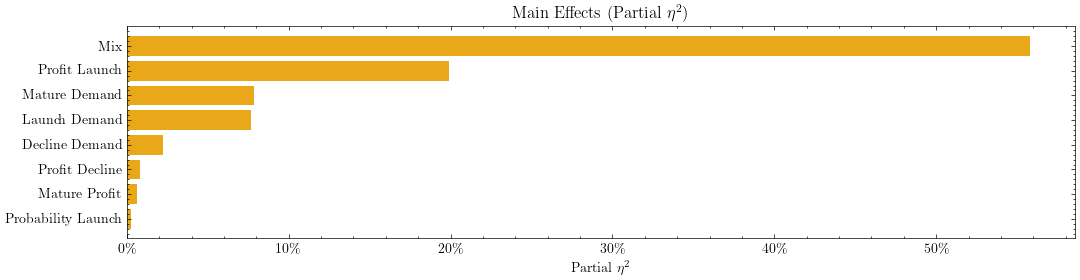

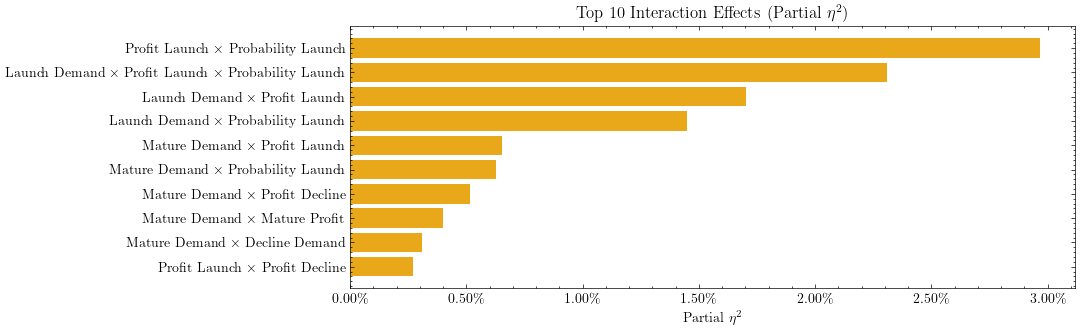

In [42]:
def clean_term(term: str) -> str:
    """
    Convert ANOVA term labels like 'C(established_demand):C(launch_demand)'
    into 'Established Demand × Launch Demand'.
    """
    parts = term.split(":")
    clean_parts = []
    for p in parts:
        # Strip C(...) wrapper
        if p.startswith("C(") and p.endswith(")"):
            p = p[2:-1]
        # Replace underscores and capitalize
        p = p.replace("_", " ").title()
        clean_parts.append(p)
    return " × ".join(clean_parts)

# --- Main effects plot
main_plot = anova_main.drop(index="Residual").copy()
main_plot = main_plot.sort_values("partial_eta_sq", ascending=True)
main_plot["label"] = [clean_term(idx) for idx in main_plot.index]

fig, ax = plt.subplots(figsize=(11,3))
ax.barh(main_plot["label"], main_plot["partial_eta_sq"], alpha=0.9)
ax.set_title("Main Effects (Partial $\eta^2$)")
ax.set_xlabel("Partial $\eta^2$")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
plt.tight_layout()
plt.savefig('effect_main.pdf')
plt.show()

# --- Top interactions plot
interactions = anova_full[anova_full.index.str.contains(":")].copy()
topk = 10
top_inter = interactions.sort_values("partial_eta_sq", ascending=False).head(topk).copy()
top_inter["label"] = [clean_term(idx) for idx in top_inter.index]

# Sort so largest at top
top_sorted = top_inter.sort_values("partial_eta_sq", ascending=True)

fig, ax = plt.subplots(figsize=(11,3.5))
ax.barh(top_sorted["label"], top_sorted["partial_eta_sq"], alpha=0.9)
ax.set_title(f"Top 10 Interaction Effects (Partial $\eta^2$)")
ax.set_xlabel("Partial $\eta^2$")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
plt.tight_layout()
plt.savefig('effect_inter.pdf')
plt.show()


In [43]:
# --- Apply to full ANOVA table
anova_full_clean = anova_full.copy()
anova_full_clean["label"] = [clean_term(idx) for idx in anova_full.index]
anova_full_clean = anova_full_clean.reset_index(inplace=False)

# Sort descending by effect size
anova_full_sorted = anova_full_clean.sort_values("partial_eta_sq", ascending=False)

# Show top 15 with clean labels
display(anova_full_sorted.head(25)[
    ["label", "sum_sq", "df", "F", "PR(>F)", "partial_eta_sq"]
])


,label,sum_sq,df,F,PR(>F),partial_eta_sq
0,Mix,8.867449e+11,14.0,188.874843,0.000000e+00,0.589412
64,Residual,6.177122e+11,1842.0,NaN,NaN,0.500000
5,Profit Launch,1.748393e+11,1.0,521.365705,8.060500e-102,0.220603
1,Mature Demand,6.007850e+10,1.0,179.152363,4.656426e-39,0.088639
2,Launch Demand,5.850712e+10,1.0,174.466554,3.996106e-38,0.086521
27,Profit Launch × Probability Launch,1.890334e+10,1.0,56.369226,9.303750e-14,0.029693
3,Decline Demand,1.619781e+10,1.0,48.301417,5.053612e-12,0.025552
52,Launch Demand × Profit Launch × Probability La...,1.459632e+10,1.0,43.525796,5.452058e-11,0.023084
16,Launch Demand × Profit Launch,1.071217e+10,1.0,31.943373,1.835742e-08,0.017046
18,Launch Demand × Probability Launch,9.095192e+09,1.0,27.121601,2.124296e-07,0.014510
